# 🌦️ Data Exploration – Weather Vietnam

**Mục tiêu notebook:**
- Khám phá cấu trúc dataset sau preprocessing
- Kiểm tra chất lượng dữ liệu (missing, duplicate, outlier)
- Thống kê mô tả, phân phối, tương quan
- Phân tích theo thời gian và theo vùng

> ✅ **Toàn bộ notebook dùng PySpark thuần — không dùng `.toPandas()`**
> Chỉ collect các aggregation nhỏ (vài trăm rows) để vẽ chart.

## 0. Setup & Spark Session

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"]  = 11
PALETTE = ["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f",
           "#edc948","#b07aa1","#ff9da7","#9c755f","#bab0ac"]

aws_access_key  = os.getenv("AWS_ACCESS_KEY_ID",     "minioadmin")
aws_secret_key  = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin123")
aws_region      = os.getenv("AWS_REGION",            "us-east-1")
minio_endpoint  = os.getenv("S3_ENDPOINT",           "http://minio:9000")
DATA_PATH       = os.getenv("BRONZE_WEATHER_PATH",   "s3a://iceberg/bronze/weather_raw_parquet/")
spark_master    = os.getenv("SPARK_MASTER_URL",      "spark://spark-master:7077")
driver_host     = os.getenv("SPARK_DRIVER_HOST",     "forecasting-spark-notebook")

existing = SparkSession.getActiveSession()
if existing is not None:
    spark = existing
    print("♻️  Reusing existing SparkSession")
else:
    spark = (
        SparkSession.builder
        .appName("Weather-Data-Exploration")
        .master(spark_master)
        .config("spark.driver.host",        driver_host)
        .config("spark.driver.bindAddress", "0.0.0.0")
        .config("spark.sql.extensions",
                "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
        .config("spark.sql.catalog.iceberg",                       "org.apache.iceberg.spark.SparkCatalog")
        .config("spark.sql.catalog.iceberg.type",                  "rest")
        .config("spark.sql.catalog.iceberg.uri",                   "http://iceberg-rest:8181")
        .config("spark.sql.catalog.iceberg.warehouse",             "s3://iceberg/warehouse")
        .config("spark.sql.catalog.iceberg.io-impl",               "org.apache.iceberg.aws.s3.S3FileIO")
        .config("spark.sql.catalog.iceberg.s3.endpoint",           minio_endpoint)
        .config("spark.sql.catalog.iceberg.s3.path-style-access",  "true")
        .config("spark.sql.catalog.iceberg.s3.access-key-id",      aws_access_key)
        .config("spark.sql.catalog.iceberg.s3.secret-access-key",  aws_secret_key)
        .config("spark.sql.catalog.iceberg.s3.region",             aws_region)
        .config("spark.hadoop.fs.s3a.endpoint",                    minio_endpoint)
        .config("spark.hadoop.fs.s3a.access.key",                  aws_access_key)
        .config("spark.hadoop.fs.s3a.secret.key",                  aws_secret_key)
        .config("spark.hadoop.fs.s3a.path.style.access",           "true")
        .config("spark.hadoop.fs.s3a.impl",                        "org.apache.hadoop.fs.s3a.S3AFileSystem")
        .config("spark.hadoop.fs.s3a.connection.ssl.enabled",      "false")
        .config("spark.hadoop.fs.s3a.fast.upload",                 "true")
        .config("spark.hadoop.fs.s3a.connection.maximum",          "100")
        .config("spark.hadoop.fs.s3a.aws.credentials.provider",
                "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .getOrCreate()
    )

spark.sparkContext.setLogLevel("ERROR")

# Load data — đọc parquet, KHÔNG toPandas()
df = spark.read.parquet(DATA_PATH)
if "time" in df.columns:
    df = df.withColumn("time", F.to_timestamp("time"))

print(f"✅ Loaded — Spark master: {spark_master}")
print(f"   MinIO: {minio_endpoint}  |  Path: {DATA_PATH}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 02:33:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Loaded — Spark master: spark://spark-master:7077
   MinIO: http://minio:9000  |  Path: s3a://iceberg/bronze/weather_raw_parquet/


---
## 1. Khám Phá Cấu Trúc Dataset
### 1.1 Schema & Shape

In [5]:
# Shape
n_rows = df.count()
n_cols = len(df.columns)
print(f"Shape: {n_rows:,} rows × {n_cols} cols")

# Schema
print("\nSchema:")
df.printSchema()

# Sample 5 rows
print("\nSample (5 rows):")
df.show(5, truncate=False)

Shape: 3,810,913 rows × 38 cols

Schema:
root
 |-- time: timestamp (nullable = true)
 |-- city: string (nullable = true)
 |-- temperature: string (nullable = true)
 |-- temp_min: string (nullable = true)
 |-- temp_max: string (nullable = true)
 |-- humidity: string (nullable = true)
 |-- feels_like: string (nullable = true)
 |-- visibility: string (nullable = true)
 |-- precipitation: string (nullable = true)
 |-- cloudcover: string (nullable = true)
 |-- wind_speed: string (nullable = true)
 |-- wind_gust: string (nullable = true)
 |-- wind_direction: string (nullable = true)
 |-- pressure: string (nullable = true)
 |-- is_day: string (nullable = true)
 |-- weather_code: string (nullable = true)
 |-- weather_main: string (nullable = true)
 |-- weather_description: string (nullable = true)
 |-- weather_icon: string (nullable = true)
 |-- hour: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- weekday: string (nullable = true)
 |-- reg

+-------------------+----------+-----------+--------+--------+--------+----------+----------+-------------+----------+----------+---------+--------------+--------+------+------------+------------+-------------------+------------+----+---+-----+-------+-------+------------------+------------+------------+----+-------+-----------+---------------+---------------+----------+----------+--------------+--------------+---------------------------------------------+--------------------------+
|time               |city      |temperature|temp_min|temp_max|humidity|feels_like|visibility|precipitation|cloudcover|wind_speed|wind_gust|wind_direction|pressure|is_day|weather_code|weather_main|weather_description|weather_icon|hour|day|month|weekday|region |temp_range        |wind_dir_sin|wind_dir_cos|rain|extreme|temp_level |humidity_level |pressure_level |wind_level|temp_lag_1|humidity_lag_1|pressure_lag_1|source_file                                  |bronze_ingested_at        |
+-------------------+---

### 1.2 Phân loại cột

In [6]:
from pyspark.sql.types import NumericType, StringType, TimestampType, BooleanType, DoubleType

# Auto-detect kiểu dữ liệu từ schema
num_cols  = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
cat_cols  = [f.name for f in df.schema.fields if isinstance(f.dataType, (StringType, BooleanType))]
time_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, TimestampType)]

# Nếu không có cột số → thử cast các cột string có vẻ là số
if not num_cols:
    print("⚠️  Không detect được cột số — thử tự động cast string → double...")
    for f in df.schema.fields:
        if isinstance(f.dataType, StringType):
            # Thử cast và kiểm tra xem có bị null hết không
            non_null = df.select(f.name).dropna().count()
            if non_null == 0:
                continue
            cast_null = df.select(df[f.name].cast(DoubleType())).filter(
                df[f.name].isNotNull() & df[f.name].cast(DoubleType()).isNull()
            ).count()
            # Nếu tỷ lệ cast thành công > 80% thì coi là cột số
            if cast_null / non_null < 0.2:
                df = df.withColumn(f.name, df[f.name].cast(DoubleType()))
                print(f"  → Cast '{f.name}' sang Double")

    # Phân loại lại sau khi cast
    num_cols  = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
    cat_cols  = [f.name for f in df.schema.fields if isinstance(f.dataType, (StringType, BooleanType))]
    time_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, TimestampType)]

print(f"Numeric  ({len(num_cols)}): {num_cols}")
print(f"Categoric({len(cat_cols)}): {cat_cols}")
print(f"Datetime ({len(time_cols)}): {time_cols}")

# Feature groups
weather_num = [c for c in num_cols
               if not c.endswith(("_lag_1","_sin","_cos"))
               and c not in ["hour","day","month","weekday","rain","weather_code","is_day"]]
print(f"\nWeather numeric features: {weather_num}")


⚠️  Không detect được cột số — thử tự động cast string → double...
  → Cast 'temperature' sang Double
  → Cast 'temp_min' sang Double
  → Cast 'temp_max' sang Double
  → Cast 'humidity' sang Double
  → Cast 'feels_like' sang Double
  → Cast 'visibility' sang Double
  → Cast 'precipitation' sang Double
  → Cast 'cloudcover' sang Double


  → Cast 'wind_speed' sang Double
  → Cast 'wind_gust' sang Double
  → Cast 'wind_direction' sang Double
  → Cast 'pressure' sang Double
  → Cast 'is_day' sang Double
  → Cast 'weather_code' sang Double
  → Cast 'hour' sang Double
  → Cast 'day' sang Double
  → Cast 'month' sang Double
  → Cast 'weekday' sang Double


  → Cast 'temp_range' sang Double
  → Cast 'wind_dir_sin' sang Double
  → Cast 'wind_dir_cos' sang Double
  → Cast 'rain' sang Double


  → Cast 'temp_lag_1' sang Double
  → Cast 'humidity_lag_1' sang Double
  → Cast 'pressure_lag_1' sang Double
Numeric  (25): ['temperature', 'temp_min', 'temp_max', 'humidity', 'feels_like', 'visibility', 'precipitation', 'cloudcover', 'wind_speed', 'wind_gust', 'wind_direction', 'pressure', 'is_day', 'weather_code', 'hour', 'day', 'month', 'weekday', 'temp_range', 'wind_dir_sin', 'wind_dir_cos', 'rain', 'temp_lag_1', 'humidity_lag_1', 'pressure_lag_1']
Categoric(11): ['city', 'weather_main', 'weather_description', 'weather_icon', 'region', 'extreme', 'temp_level', 'humidity_level', 'pressure_level', 'wind_level', 'source_file']
Datetime (2): ['time', 'bronze_ingested_at']

Weather numeric features: ['temperature', 'temp_min', 'temp_max', 'humidity', 'feels_like', 'visibility', 'precipitation', 'cloudcover', 'wind_speed', 'wind_gust', 'wind_direction', 'pressure', 'temp_range']


### 1.3 Khoảng thời gian dữ liệu

In [7]:
time_stats = df.agg(
    F.min("time").alias("start"),
    F.max("time").alias("end"),
    F.countDistinct("time").alias("unique_timestamps")
).collect()[0]

print(f"Từ  : {time_stats['start']}")
print(f"Đến : {time_stats['end']}")
print(f"Unique timestamps: {time_stats['unique_timestamps']:,}")

# Số thành phố
for city_col in ["city", "province", "location"]:
    if city_col in df.columns:
        n_city = df.select(F.countDistinct(city_col)).collect()[0][0]
        print(f"\nSố {city_col}: {n_city}")
        print("Top 10:")
        df.groupBy(city_col).count().orderBy(F.desc("count")).show(10, truncate=False)
        break

Từ  : 2025-06-29 23:29:17
Đến : 2025-11-03 09:12:06
Unique timestamps: 360,416

Số city: 78
Top 10:
+-------------+-----+
|city         |count|
+-------------+-----+
|Lang Son     |92928|
|Ha Noi       |48546|
|Hai Phong    |48505|
|Da Nang      |48471|
|Ho Chi Minh  |48453|
|Can Tho      |48431|
|Cao Bang     |48412|
|Ha Giang     |48408|
|Lao Cai      |48397|
|Dien Bien Phu|48378|
+-------------+-----+
only showing top 10 rows



---
## 2. Kiểm Tra Chất Lượng Dữ Liệu
### 2.1 Missing values

Column                            Missing      Pct
----------------------------------------------------
wind_level                          9,239    0.24%
temp_lag_1                             78    0.00%
humidity_lag_1                         78    0.00%
pressure_lag_1                         78    0.00%


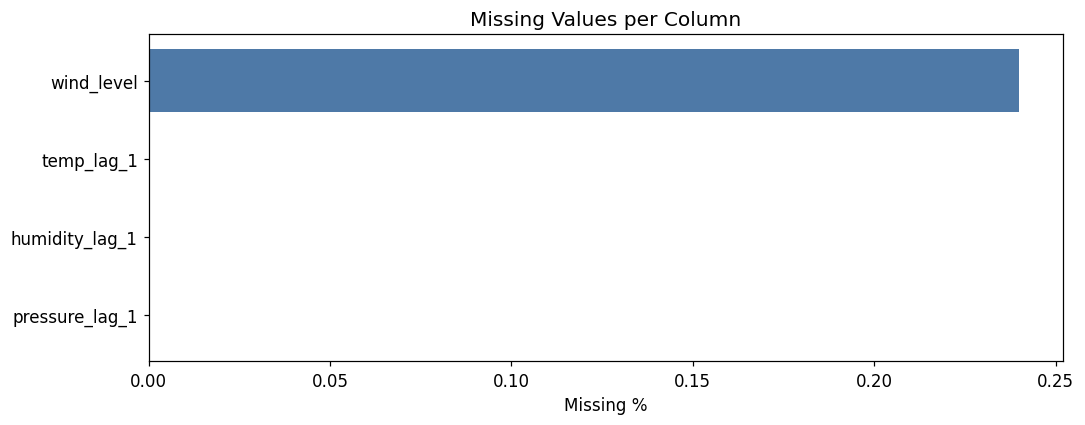

In [8]:
# Đếm null theo từng cột — collect 1 row duy nhất (an toàn)
null_exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
null_counts = df.agg(*null_exprs).collect()[0].asDict()

missing = [(col, cnt, round(cnt/n_rows*100, 2))
           for col, cnt in null_counts.items() if cnt > 0]
missing.sort(key=lambda x: -x[1])

if not missing:
    print("✅ Không có missing values sau preprocessing!")
else:
    print(f"{'Column':<30} {'Missing':>10} {'Pct':>8}")
    print("-" * 52)
    for col, cnt, pct in missing:
        print(f"{col:<30} {cnt:>10,} {pct:>7.2f}%")

    # Bar chart
    cols_m = [m[0] for m in missing[:20]]
    pcts_m = [m[2] for m in missing[:20]]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(cols_m[::-1], pcts_m[::-1], color="#4e79a7")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values per Column")
    plt.tight_layout()
    plt.show()

### 2.2 Duplicates

In [9]:
total     = df.count()
distinct  = df.distinct().count()
dup_count = total - distinct
print(f"Total rows    : {total:,}")
print(f"Distinct rows : {distinct:,}")
print(f"Duplicates    : {dup_count:,}  ({dup_count/total*100:.2f}%)")

[Stage 244:>                                                        (0 + 2) / 8]

Total rows    : 3,810,913
Distinct rows : 3,810,913
Duplicates    : 0  (0.00%)


### 2.3 Class imbalance – cột `extreme`

Class                     Count      Pct
------------------------------------------
normal                3,751,765   98.45%
heatwave                 59,148    1.55%


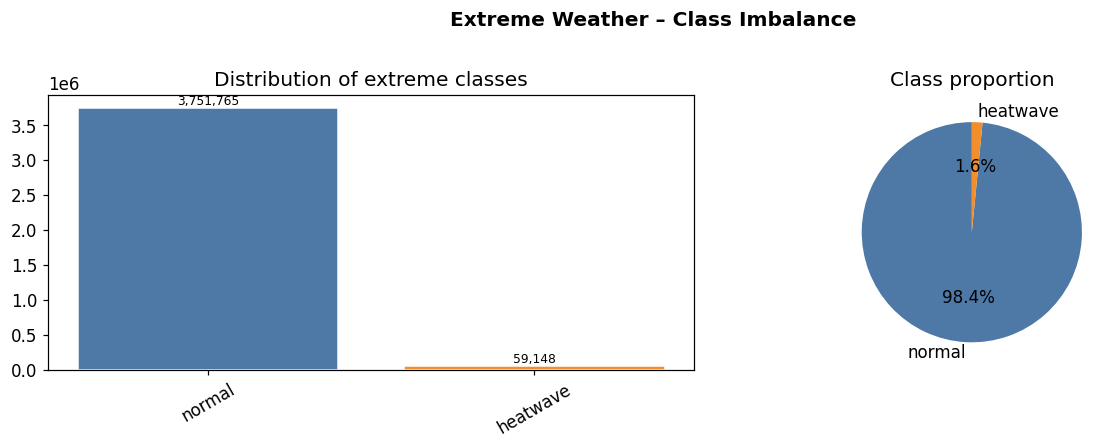

⚠️  Imbalance cao: class dominates 98.45% → cân nhắc SMOTE / class_weight


In [14]:
if "extreme" in df.columns:
    vc = (df.groupBy("extreme").count()
            .withColumn("pct", F.round(F.col("count")/n_rows*100, 2))
            .orderBy(F.desc("count"))
            .collect())

    print(f"{'Class':<20} {'Count':>10} {'Pct':>8}")
    print("-" * 42)
    for row in vc:
        print(f"{row['extreme']:<20} {row['count']:>10,} {row['pct']:>7.2f}%")

    labels = [r["extreme"] for r in vc]
    counts = [r["count"]   for r in vc]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(labels, counts, color=PALETTE[:len(labels)], edgecolor="white")
    axes[0].set_title("Distribution of extreme classes")
    axes[0].tick_params(axis="x", rotation=30)
    for bar, v in zip(axes[0].patches, counts):
        axes[0].text(bar.get_x()+bar.get_width()/2, v, f"{v:,}",
                     ha="center", va="bottom", fontsize=8)
    axes[1].pie(counts, labels=labels, autopct="%1.1f%%",
                colors=PALETTE[:len(labels)], startangle=90)
    axes[1].set_title("Class proportion")
    plt.suptitle("Extreme Weather – Class Imbalance", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    majority_pct = max(r["pct"] for r in vc)
    if majority_pct > 70:
        print(f"⚠️  Imbalance cao: class dominates {majority_pct}% → cân nhắc SMOTE / class_weight")
    else:
        print("✅ Imbalance ở mức chấp nhận được.")

### 2.4 Outliers (IQR method)

In [13]:
# Tính Q1, Q3 trên Spark rồi collect — chỉ 1 row per column
outlier_rows = []
for col in weather_num:
    stats_row = df.select(
        F.percentile_approx(col, 0.25).alias("q1"),
        F.percentile_approx(col, 0.75).alias("q3"),
    ).collect()[0]
    q1, q3 = stats_row["q1"], stats_row["q3"]
    if q1 is None or q3 is None:
        continue
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = df.filter((F.col(col) < lo) | (F.col(col) > hi)).count()
    outlier_rows.append((col, n_out, round(n_out/n_rows*100, 2)))

outlier_rows.sort(key=lambda x: -x[1])
print(f"{'Column':<28} {'Outliers':>10} {'Pct':>8}")
print("-" * 50)
for col, n, pct in outlier_rows:
    flag = " ⚠️" if pct > 5 else ""
    print(f"{col:<28} {n:>10,} {pct:>7.2f}%{flag}")

Column                         Outliers      Pct
--------------------------------------------------
precipitation                   511,659   13.43% ⚠️
visibility                      320,043    8.40% ⚠️
pressure                        237,430    6.23% ⚠️
cloudcover                      224,955    5.90% ⚠️
wind_speed                      129,409    3.40%
wind_gust                        40,323    1.06%
temperature                      35,954    0.94%
temp_max                         35,515    0.93%
temp_min                         35,342    0.93%
temp_range                       18,716    0.49%
humidity                         17,462    0.46%
feels_like                           48    0.00%
wind_direction                        0    0.00%


---
## 3. Thống Kê Mô Tả
### 3.1 Describe (Spark native)

In [54]:
df.select(weather_num).describe().show(truncate=False)

[Stage 537:======================================>                  (2 + 1) / 3]

+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+
|summary|temperature      |temp_min          |temp_max          |humidity          |feels_like        |visibility        |precipitation     |cloudcover       |wind_speed        |wind_gust         |wind_direction   |pressure          |temp_range        |
+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+
|count  |3810913          |3810913           |3810913           |3810913           |3810913           |3810913           |3810913           |3810913          |3810913           |3810913           |3810913          |3810913           |3810

### 3.2 Histogram từng biến số

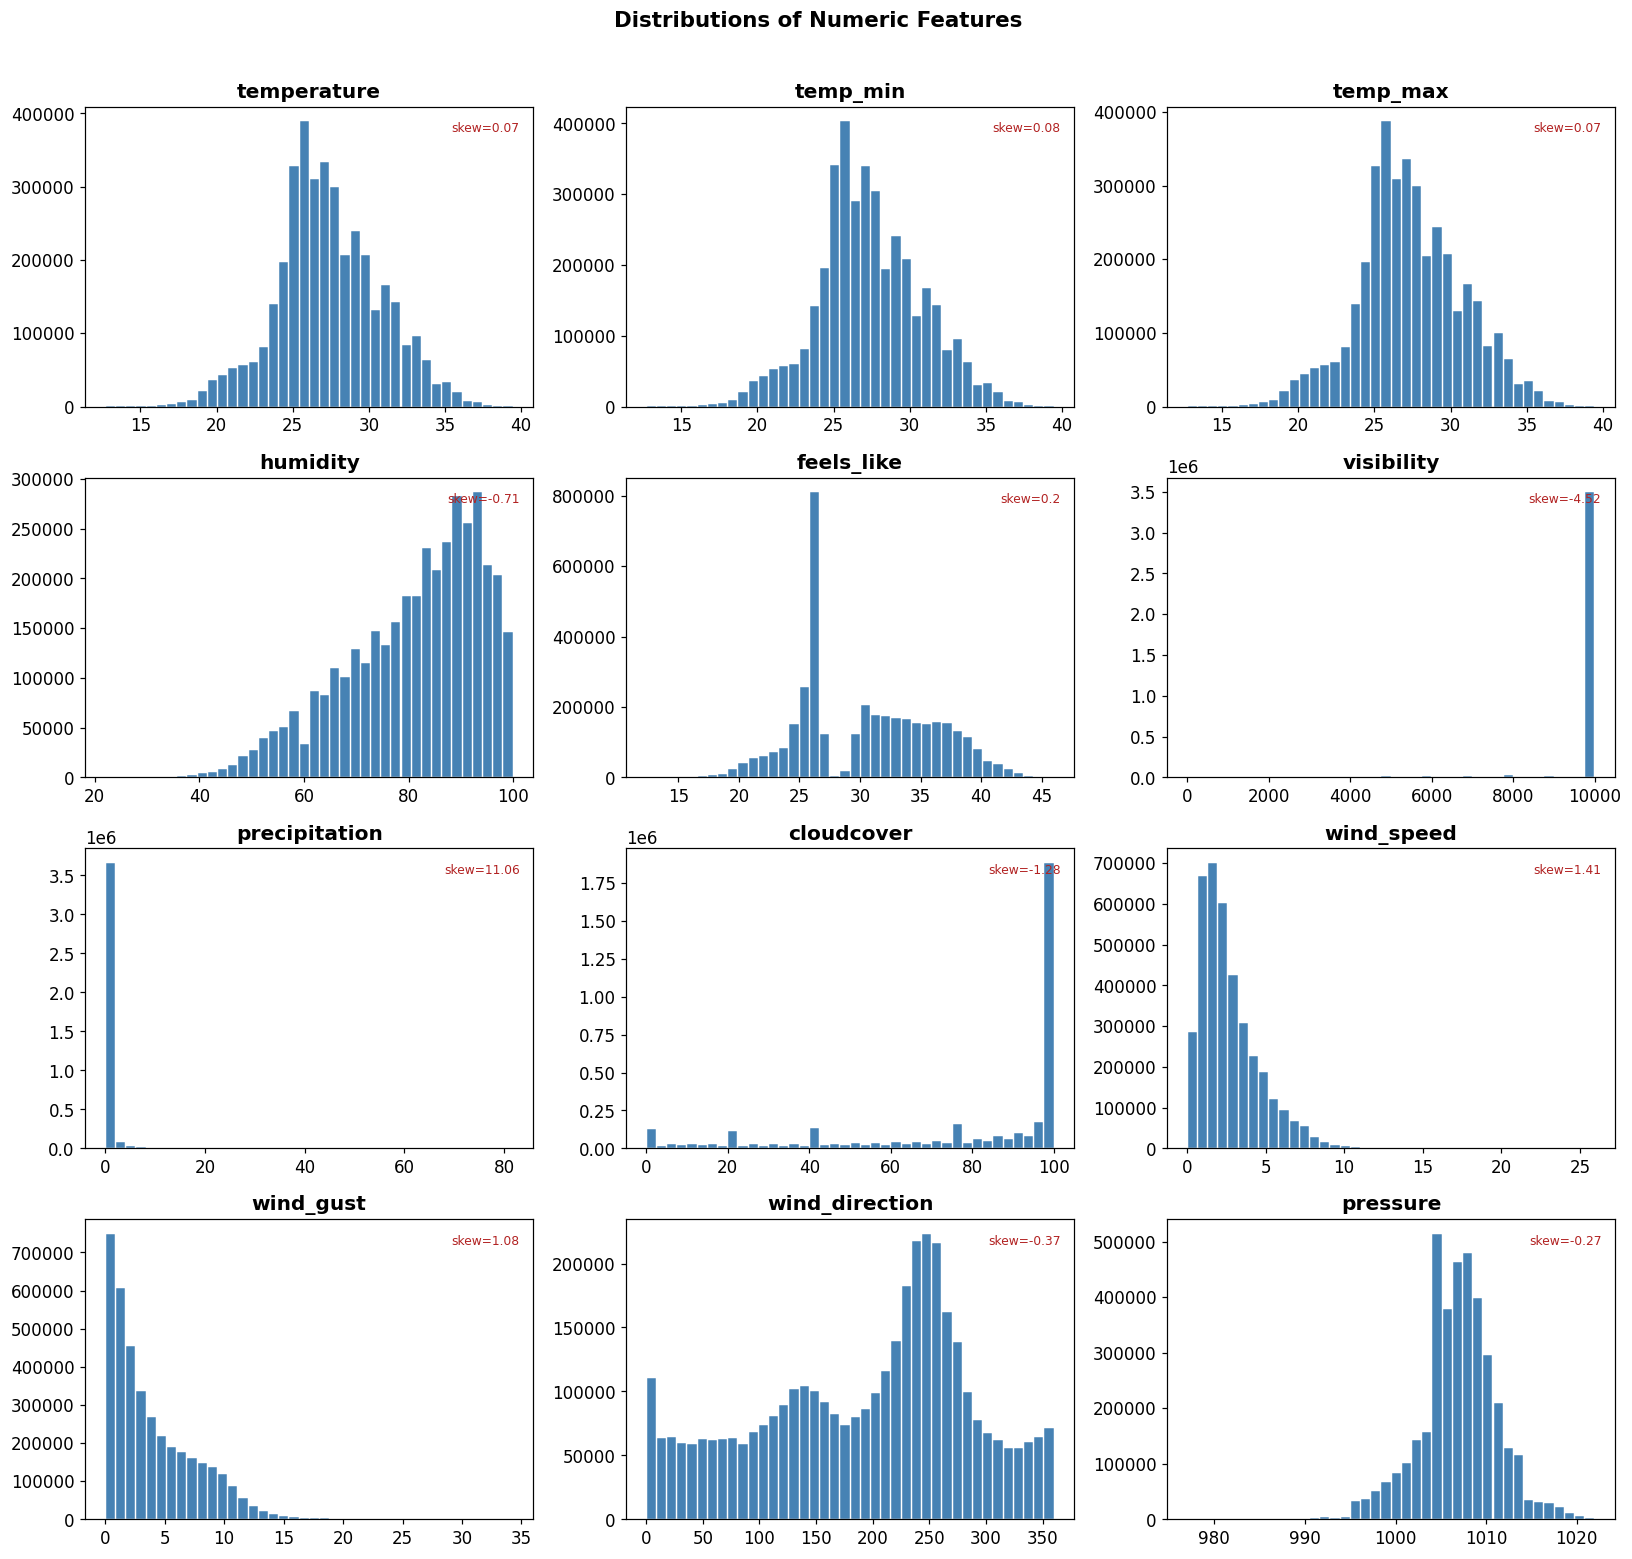

In [15]:
# Dùng df.approxQuantile + bucketizer để tạo histogram trên Spark
# rồi collect (array nhỏ) để vẽ matplotlib

cols_to_plot = weather_num[:12]
n = len(cols_to_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

N_BINS = 40

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    # Tính min/max
    mm = df.agg(F.min(col).alias("mn"), F.max(col).alias("mx")).collect()[0]
    mn, mx = mm["mn"], mm["mx"]
    if mn is None or mx is None or mn == mx:
        ax.set_visible(False)
        continue

    # Tính skewness
    skew_val = df.select(F.skewness(col)).collect()[0][0]
    skew_val = round(skew_val, 2) if skew_val is not None else "N/A"

    # Histogram via RDD histogram method
    step = (mx - mn) / N_BINS
    buckets = [mn + i * step for i in range(N_BINS + 1)]
    counts = (df.select(col)
                .dropna()
                .rdd.flatMap(lambda r: [r[0]])
                .histogram(buckets)[1])

    centers = [(buckets[i] + buckets[i+1]) / 2 for i in range(N_BINS)]
    ax.bar(centers, counts, width=step*0.9, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.text(0.97, 0.95, f"skew={skew_val}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="firebrick")

for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Numeric Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Boxplots

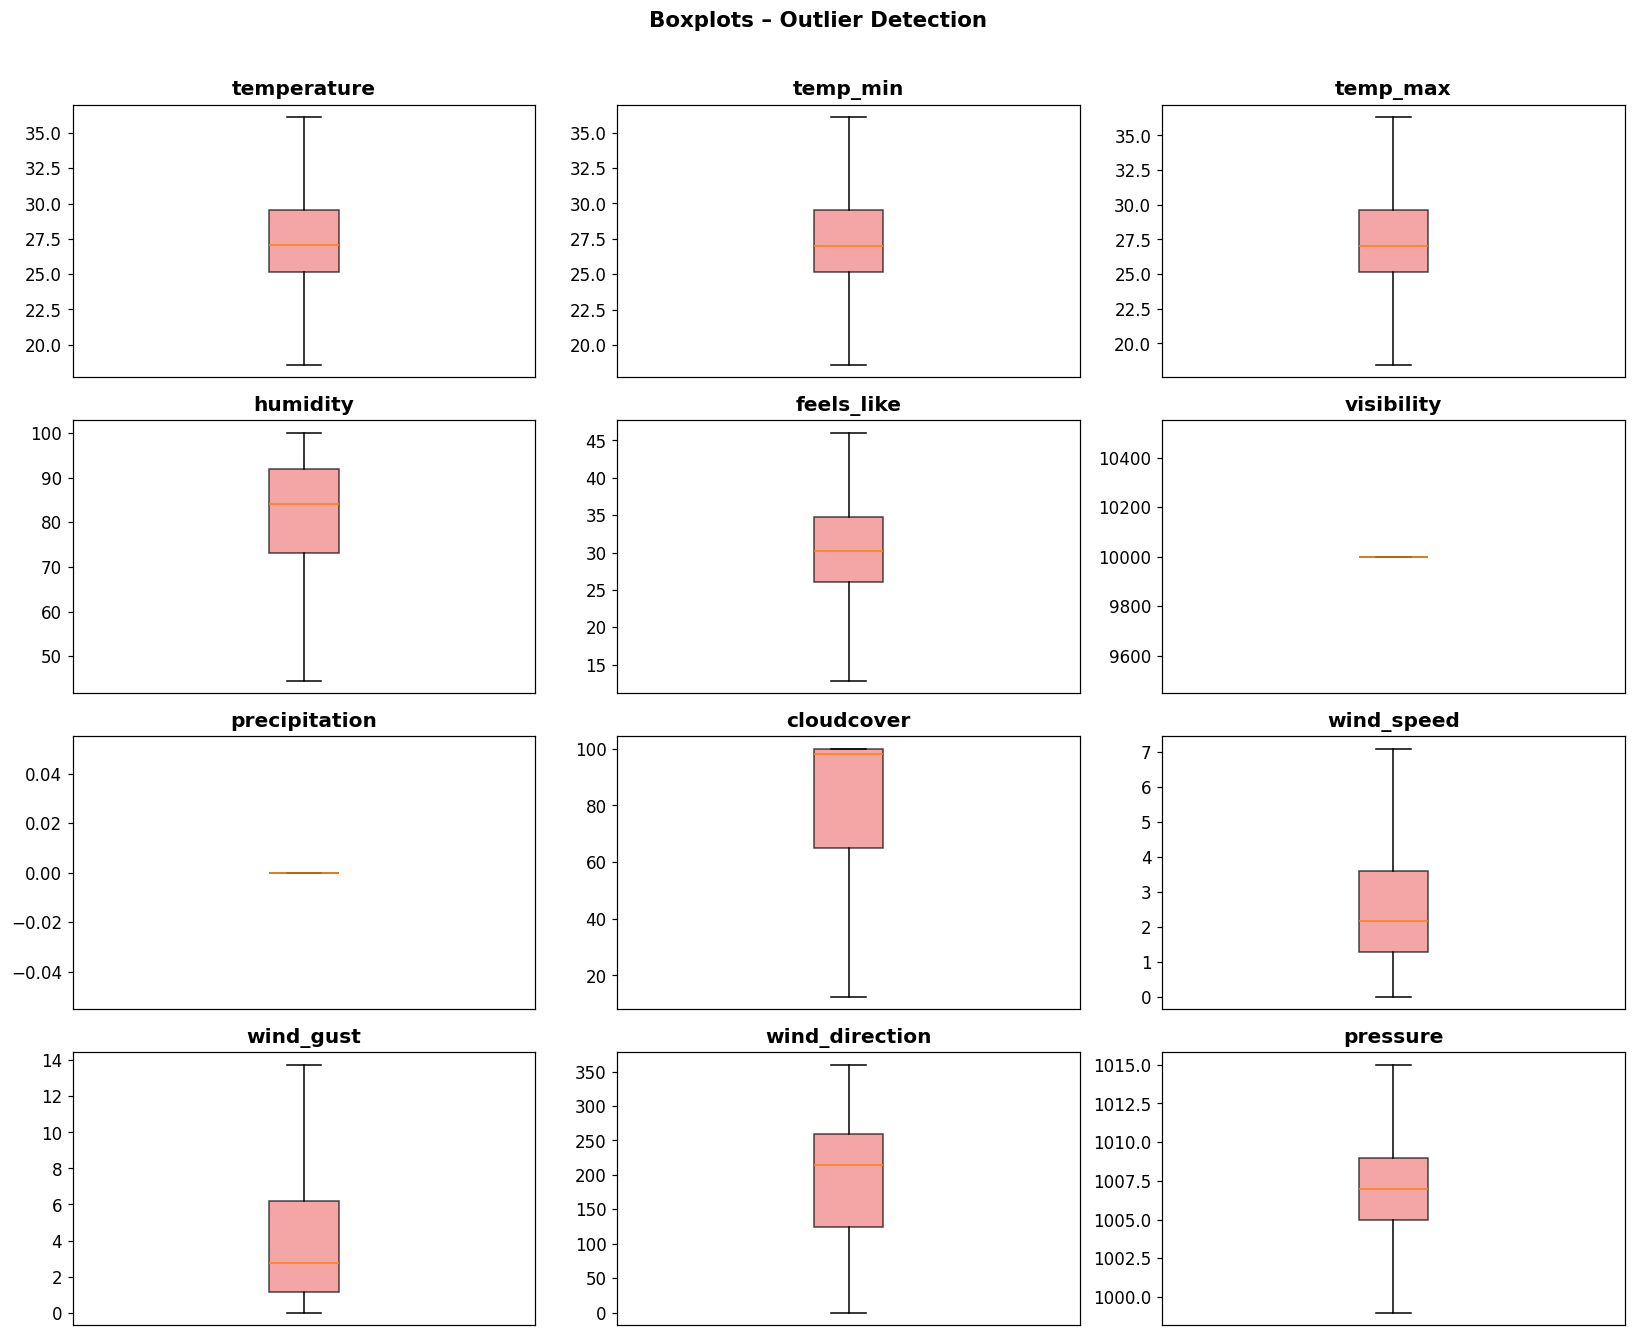

In [16]:
# Dùng approxQuantile để collect thống kê boxplot từng cột
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    qs = df.approxQuantile(col, [0.0, 0.25, 0.5, 0.75, 1.0], 0.01)
    if not qs or len(qs) < 5:
        ax.set_visible(False)
        continue
    mn, q1, med, q3, mx = qs
    iqr = q3 - q1
    whisker_lo = max(mn, q1 - 1.5*iqr)
    whisker_hi = min(mx, q3 + 1.5*iqr)

    ax.bxp([{
        "med": med, "q1": q1, "q3": q3,
        "whislo": whisker_lo, "whishi": whisker_hi,
        "fliers": []
    }], vert=True, patch_artist=True,
       boxprops=dict(facecolor="lightcoral", alpha=0.7))
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xticks([])

for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots – Outlier Detection", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation heatmap

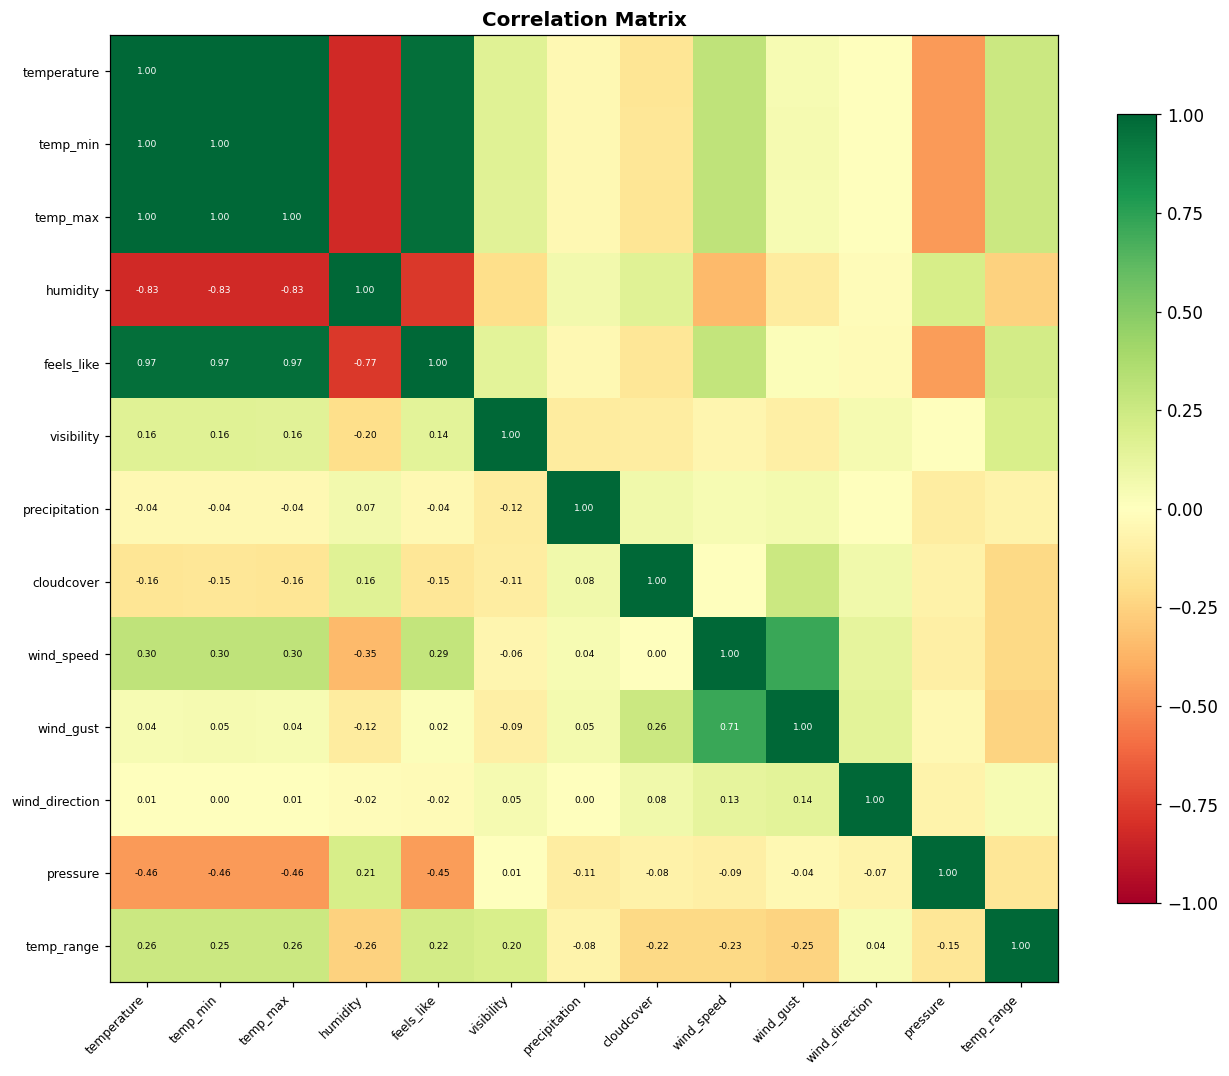

In [18]:
# Tính correlation matrix bằng Spark (collect ma trận nhỏ n_features × n_features)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

corr_cols = [c for c in weather_num if c in df.columns]
df_vec = VectorAssembler(inputCols=corr_cols, outputCol="_vec", handleInvalid="skip")           .transform(df.select(corr_cols).dropna())

corr_matrix = Correlation.corr(df_vec, "_vec").collect()[0][0].toArray()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        if i >= j:
            ax.text(j, i, f"{corr_matrix[i,j]:.2f}",
                    ha="center", va="center", fontsize=6,
                    color="black" if abs(corr_matrix[i,j]) < 0.7 else "white")

ax.set_title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Phân Tích Theo Vùng (Region / City)

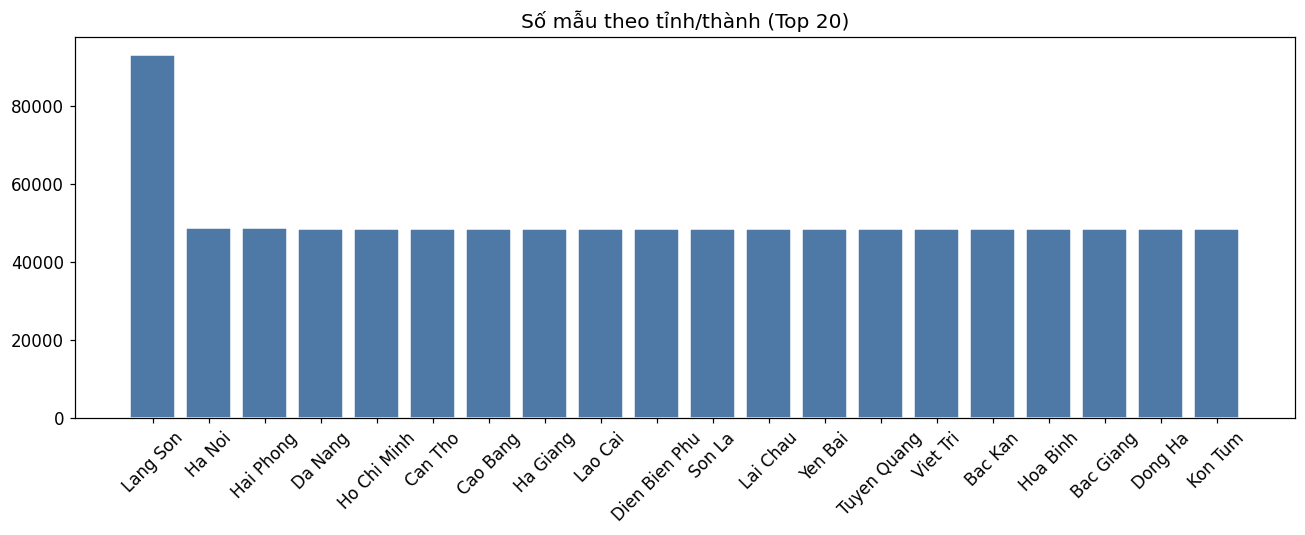

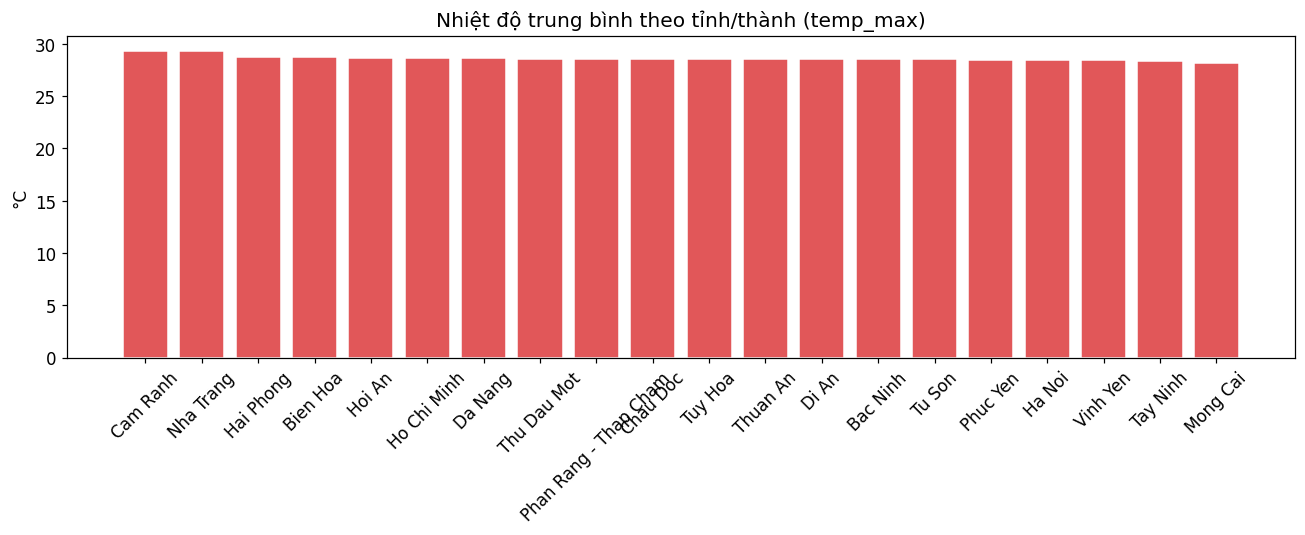

In [19]:
city_col = next((c for c in ["city","province","location"] if c in df.columns), None)

if city_col is None:
    print("⚠️  Không tìm thấy cột city/province.")
else:
    # Số mẫu theo thành phố
    city_counts = (df.groupBy(city_col).count()
                     .orderBy(F.desc("count"))
                     .limit(20)
                     .collect())
    cities = [r[city_col] for r in city_counts]
    counts = [r["count"]  for r in city_counts]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(cities, counts, color=PALETTE[0], edgecolor="white")
    ax.set_title("Số mẫu theo tỉnh/thành (Top 20)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    # Nhiệt độ trung bình theo thành phố
    temp_col = next((c for c in ["temp_max","temperature","temp"] if c in df.columns), None)
    if temp_col:
        city_temp = (df.groupBy(city_col)
                       .agg(F.round(F.avg(temp_col), 2).alias("avg_temp"))
                       .orderBy(F.desc("avg_temp"))
                       .limit(20)
                       .collect())
        c_cities = [r[city_col] for r in city_temp]
        c_temps  = [r["avg_temp"] for r in city_temp]

        fig, ax = plt.subplots(figsize=(12, 5))
        bars = ax.bar(c_cities, c_temps, color=PALETTE[2], edgecolor="white")
        ax.set_title(f"Nhiệt độ trung bình theo tỉnh/thành ({temp_col})")
        ax.set_ylabel("°C")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()

---
## 5. Phân Tích Theo Thời Gian
### 5.1 Trend nhiệt độ theo tháng

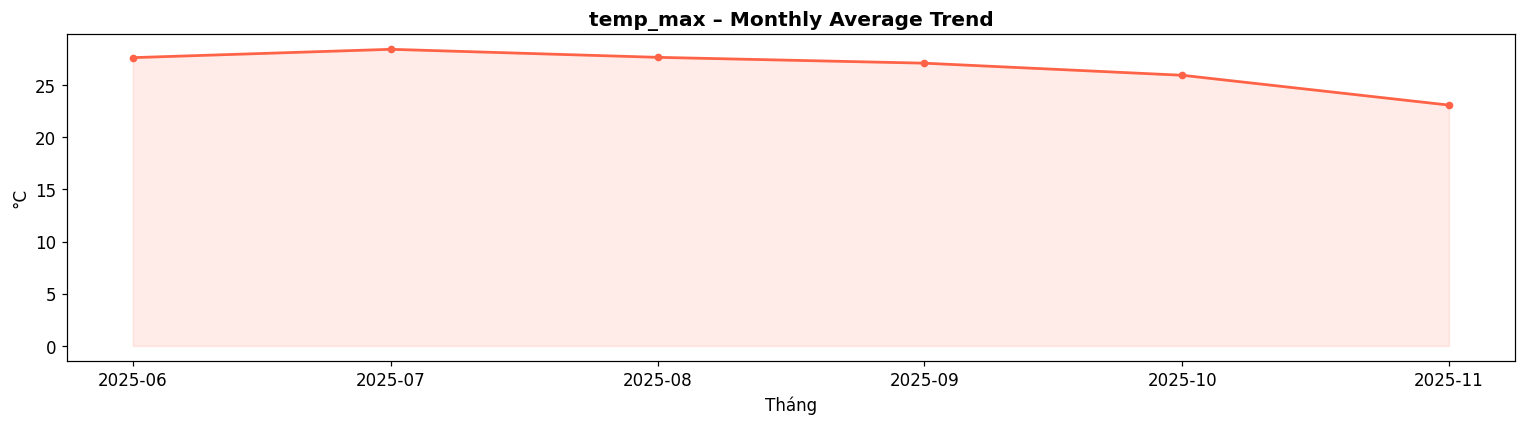

In [20]:
temp_col = next((c for c in ["temp_max","temperature","temp"] if c in df.columns), None)

if temp_col and "time" in df.columns:
    monthly = (df.groupBy(F.trunc("time", "month").alias("month"))
                 .agg(F.round(F.avg(temp_col), 2).alias("avg_temp"))
                 .orderBy("month")
                 .collect())

    months = [r["month"] for r in monthly]
    temps  = [r["avg_temp"] for r in monthly]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(months, temps, color="tomato", linewidth=1.8, marker="o", markersize=4)
    ax.fill_between(months, temps, alpha=0.12, color="tomato")
    ax.set_title(f"{temp_col} – Monthly Average Trend", fontweight="bold")
    ax.set_xlabel("Tháng")
    ax.set_ylabel("°C")
    plt.tight_layout()
    plt.show()

### 5.2 Seasonality – phân phối theo tháng

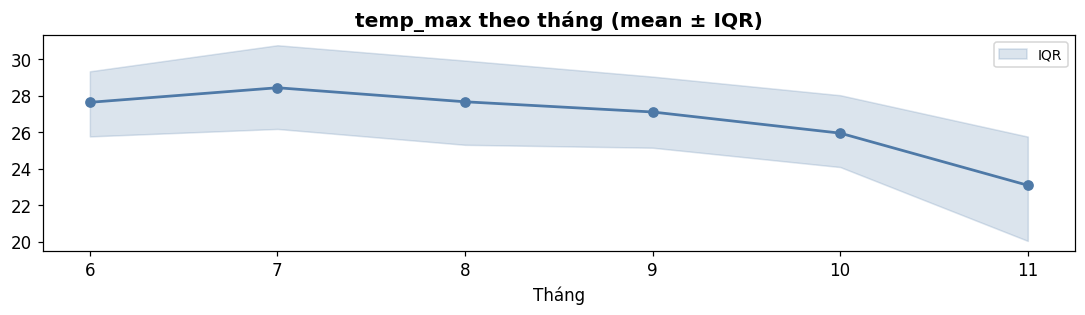

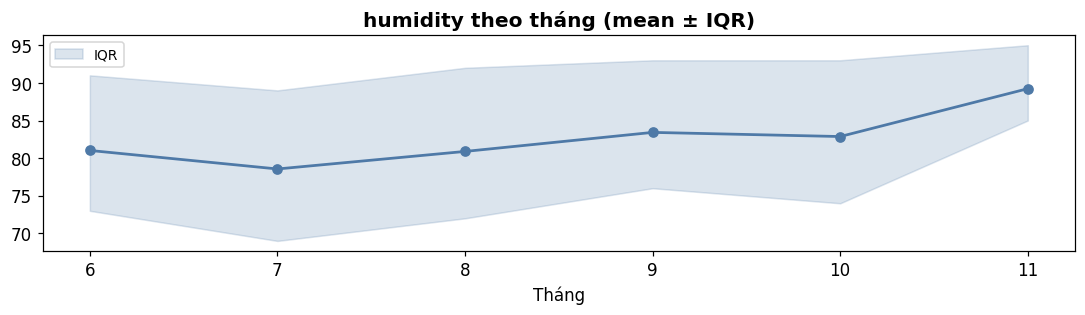

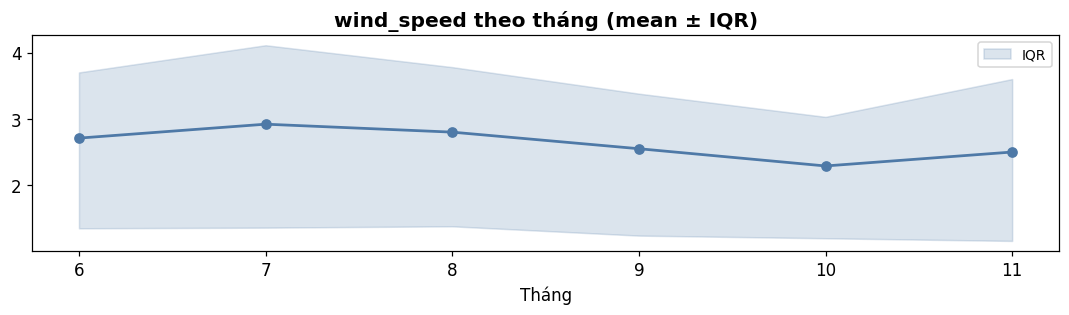

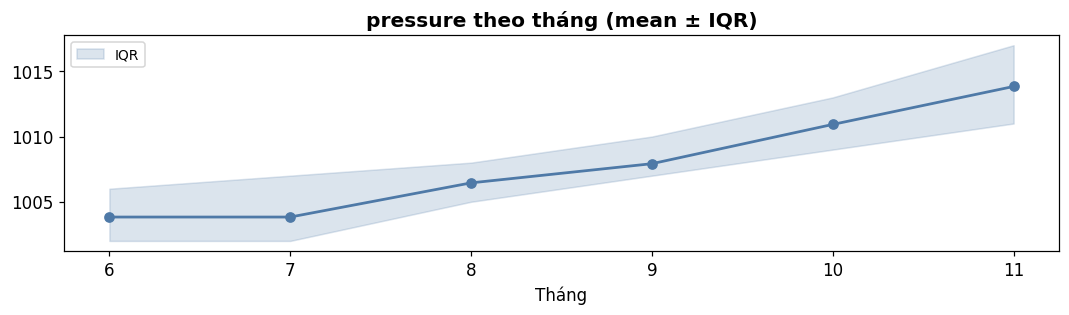

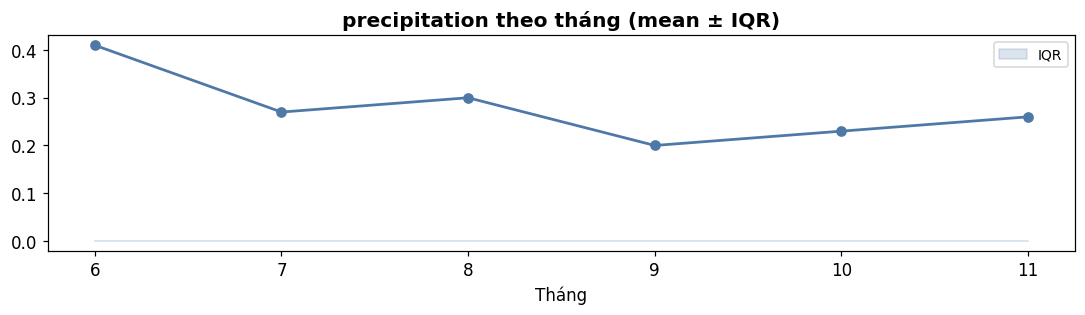

In [21]:
season_vars = [c for c in ["temp_max","humidity","wind_speed","pressure","precipitation"]
               if c in df.columns]

if "month" in df.columns and season_vars:
    # Collect median + IQR theo tháng cho mỗi biến
    for s_col in season_vars:
        month_stats = (df.groupBy("month")
                         .agg(
                             F.round(F.avg(s_col), 2).alias("mean"),
                             F.round(F.percentile_approx(s_col, 0.25), 2).alias("q1"),
                             F.round(F.percentile_approx(s_col, 0.75), 2).alias("q3"),
                         )
                         .orderBy("month")
                         .collect())

        xs     = [r["month"] for r in month_stats]
        means  = [r["mean"]  for r in month_stats]
        q1s    = [r["q1"]    for r in month_stats]
        q3s    = [r["q3"]    for r in month_stats]

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(xs, means, marker="o", color=PALETTE[0], linewidth=1.8)
        ax.fill_between(xs, q1s, q3s, alpha=0.2, color=PALETTE[0], label="IQR")
        ax.set_title(f"{s_col} theo tháng (mean ± IQR)", fontweight="bold")
        ax.set_xlabel("Tháng")
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

### 5.3 Intra-day pattern – theo giờ

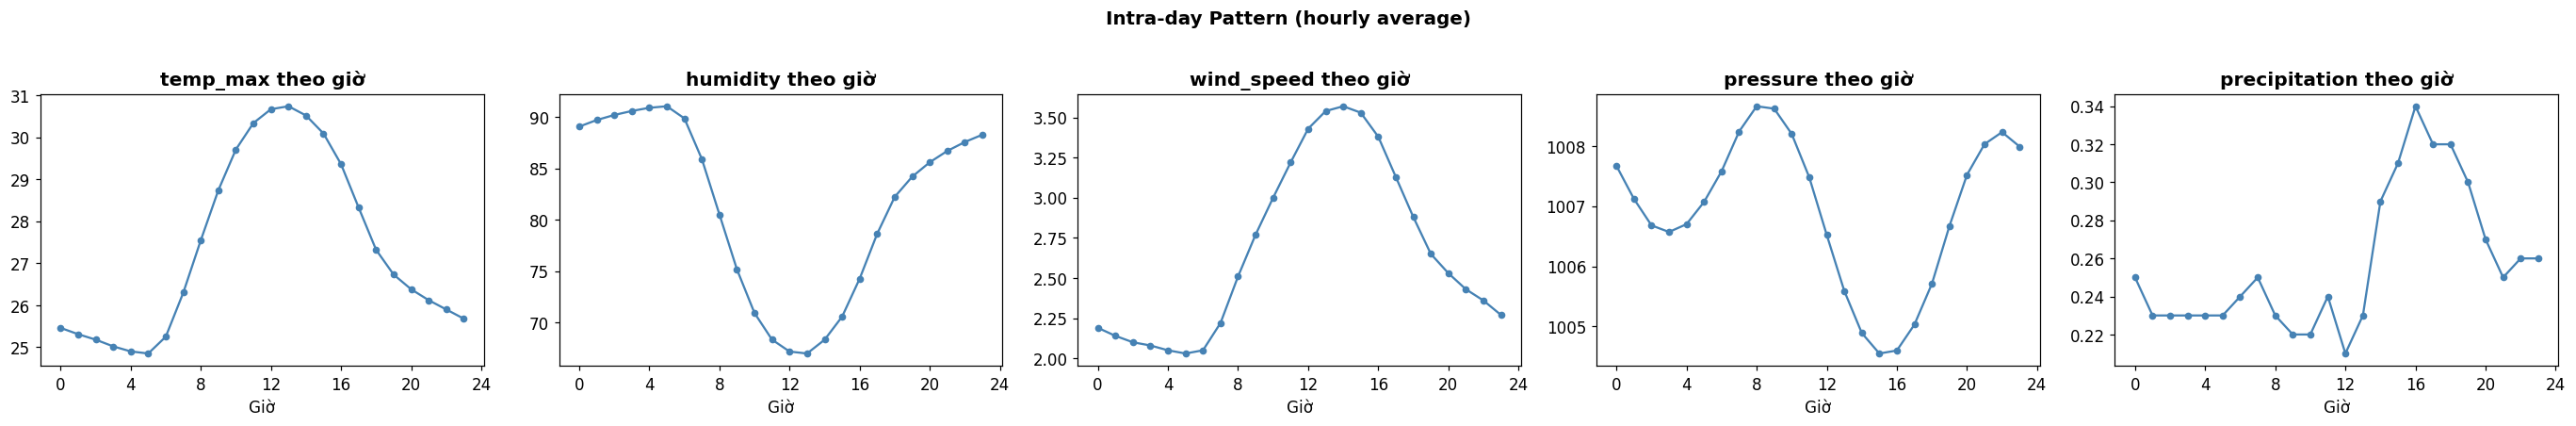

In [22]:
if "hour" in df.columns and season_vars:
    hourly = (df.groupBy("hour")
                .agg(*[F.round(F.avg(c), 2).alias(c) for c in season_vars])
                .orderBy("hour")
                .collect())

    hours = [r["hour"] for r in hourly]
    fig, axes = plt.subplots(1, len(season_vars), figsize=(5*len(season_vars), 4))
    if len(season_vars) == 1:
        axes = [axes]

    for ax, col in zip(axes, season_vars):
        vals = [r[col] for r in hourly]
        ax.plot(hours, vals, marker="o", markersize=4, color="steelblue", linewidth=1.5)
        ax.set_title(f"{col} theo giờ", fontweight="bold")
        ax.set_xlabel("Giờ")
        ax.xaxis.set_major_locator(mticker.MultipleLocator(4))

    plt.suptitle("Intra-day Pattern (hourly average)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

### 5.4 Heatmap nhiệt độ (tháng × giờ)

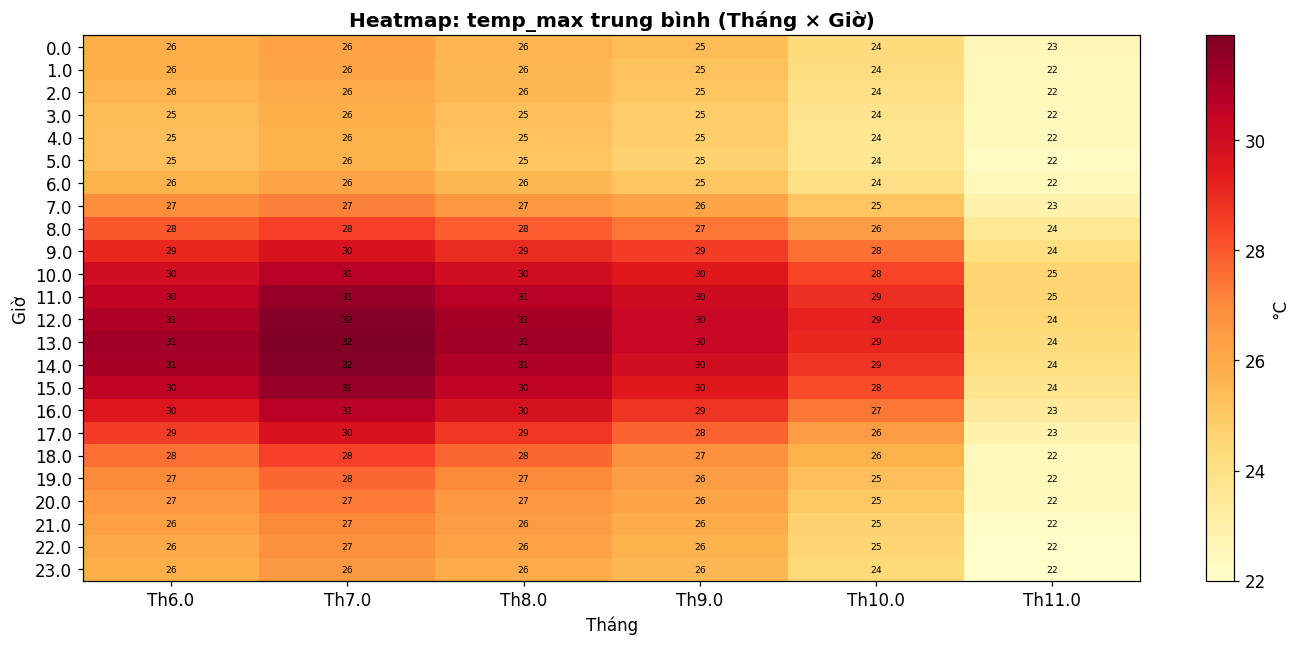

In [23]:
if temp_col and "month" in df.columns and "hour" in df.columns:
    pivot_data = (df.groupBy("month", "hour")
                    .agg(F.round(F.avg(temp_col), 1).alias("avg_temp"))
                    .orderBy("month", "hour")
                    .collect())

    # Build matrix
    months_u = sorted(set(r["month"] for r in pivot_data))
    hours_u  = sorted(set(r["hour"]  for r in pivot_data))
    val_map  = {(r["month"], r["hour"]): r["avg_temp"] for r in pivot_data}
    matrix   = [[val_map.get((m, h), float("nan")) for m in months_u] for h in hours_u]

    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(months_u)))
    ax.set_xticklabels([f"Th{m}" for m in months_u])
    ax.set_yticks(range(len(hours_u)))
    ax.set_yticklabels(hours_u)
    plt.colorbar(im, ax=ax, label="°C")
    for i, h in enumerate(hours_u):
        for j, m in enumerate(months_u):
            v = val_map.get((m, h))
            if v is not None:
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        fontsize=6, color="black" if v < 32 else "white")
    ax.set_title(f"Heatmap: {temp_col} trung bình (Tháng × Giờ)", fontweight="bold")
    ax.set_xlabel("Tháng")
    ax.set_ylabel("Giờ")
    plt.tight_layout()
    plt.show()

### 5.5 Extreme events theo tháng

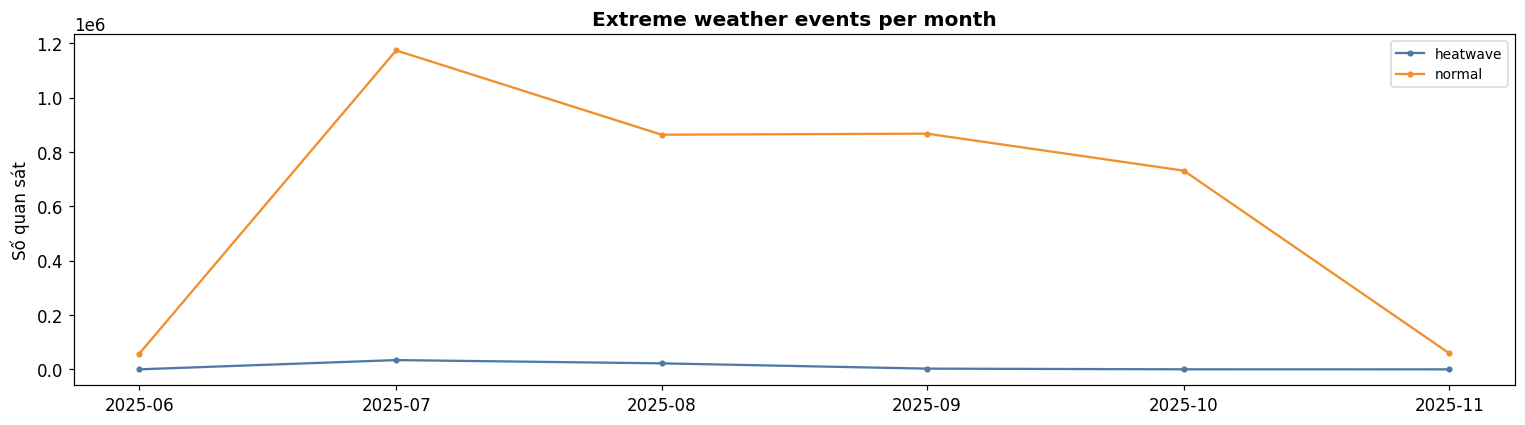

In [24]:
if "extreme" in df.columns and "time" in df.columns:
    ext_monthly = (df.groupBy(F.trunc("time","month").alias("month"), "extreme")
                     .count()
                     .orderBy("month","extreme")
                     .collect())

    months_all   = sorted(set(r["month"] for r in ext_monthly))
    classes_all  = sorted(set(r["extreme"] for r in ext_monthly))
    val_map_ext  = {(r["month"], r["extreme"]): r["count"] for r in ext_monthly}

    fig, ax = plt.subplots(figsize=(14, 4))
    for i, cls in enumerate(classes_all):
        ys = [val_map_ext.get((m, cls), 0) for m in months_all]
        ax.plot(months_all, ys, marker="o", markersize=3,
                color=PALETTE[i % len(PALETTE)], label=cls, linewidth=1.5)
    ax.set_title("Extreme weather events per month", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Số quan sát")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 6. Feature Engineering – Kiểm Tra Preprocessing
### 6.1 Lag features

In [25]:
lag_cols = [c for c in df.columns if "_lag_" in c]
print("Lag features:", lag_cols)

if lag_cols:
    lag_stats = (df.select(
        *[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in lag_cols]
    ).collect()[0].asDict())
    print("\nNull trong lag features (do shift ở đầu chuỗi):")
    for c, v in lag_stats.items():
        print(f"  {c:<30} {v:>8,} null")
    print("→ Cần dropna() trước khi train ML")

# Scatter lag vs original (sample nhỏ qua Spark)
temp_col = next((c for c in ["temp_max","temperature"] if c in df.columns), None)
lag_temp = f"{temp_col}_lag_1" if temp_col else None
if lag_temp and lag_temp in df.columns:
    sample_data = (df.select(temp_col, lag_temp)
                     .dropna()
                     .sample(fraction=0.01, seed=42)
                     .collect())
    xs = [r[lag_temp] for r in sample_data]
    ys = [r[temp_col] for r in sample_data]
    corr_val = df.select(F.corr(temp_col, lag_temp)).collect()[0][0]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(xs, ys, alpha=0.3, s=8, color="steelblue")
    ax.set_xlabel(f"{lag_temp} (t-1)")
    ax.set_ylabel(f"{temp_col} (t)")
    ax.set_title(f"Autocorrelation — r={corr_val:.3f}", fontweight="bold")
    plt.tight_layout()
    plt.show()

Lag features: ['temp_lag_1', 'humidity_lag_1', 'pressure_lag_1']

Null trong lag features (do shift ở đầu chuỗi):
  temp_lag_1                           78 null
  humidity_lag_1                       78 null
  pressure_lag_1                       78 null
→ Cần dropna() trước khi train ML


### 6.2 Discretized level columns

Level columns: ['temp_level', 'humidity_level', 'pressure_level']


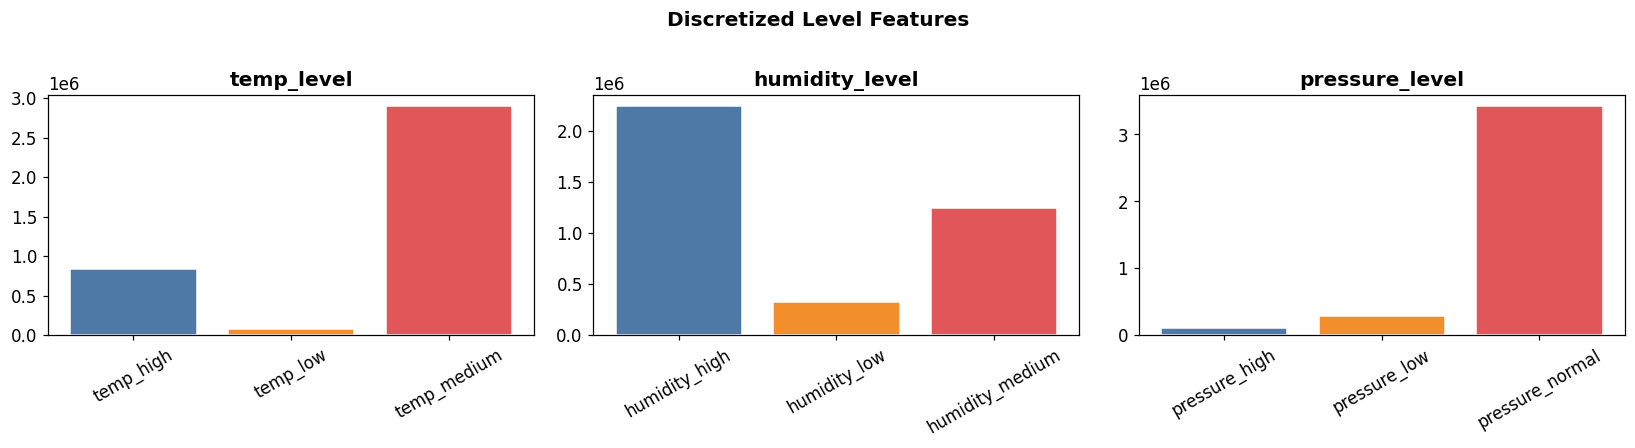

In [27]:
level_col = [c for c in df.columns if c.endswith("_level")]
level_cols = level_col[:3]
print("Level columns:", level_cols)

if level_cols:
    n = len(level_cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, level_cols):
        vc = (df.groupBy(col).count()
                .orderBy(col)
                .collect())
        labels = [r[col] for r in vc]
        counts = [r["count"] for r in vc]
        ax.bar(labels, counts, color=PALETTE[:len(labels)], edgecolor="white")
        ax.set_title(col, fontweight="bold")
        ax.tick_params(axis="x", rotation=30)

    plt.suptitle("Discretized Level Features", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

### 6.3 Wind direction – sin/cos encoding

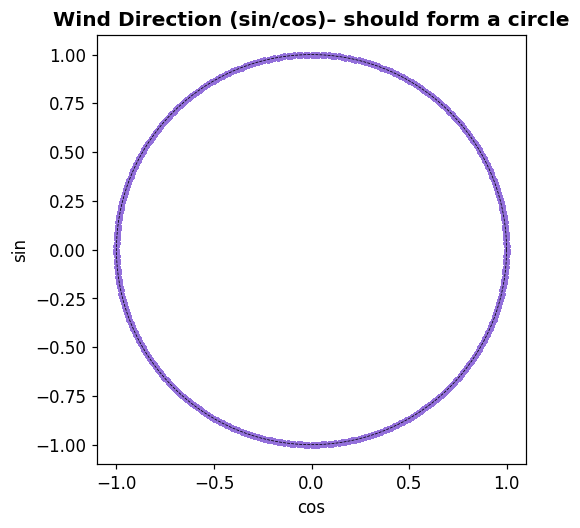

In [30]:
if "wind_dir_sin" in df.columns and "wind_dir_cos" in df.columns:
    sample_wind = (df.select("wind_dir_sin", "wind_dir_cos")
                     .dropna()
                     .sample(fraction=0.02, seed=1)
                     .collect())
    xs = [r["wind_dir_cos"] for r in sample_wind]
    ys = [r["wind_dir_sin"] for r in sample_wind]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(xs, ys, alpha=0.2, s=8, color="mediumpurple")
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.5)
    ax.set_aspect("equal")
    ax.set_title("Wind Direction (sin/cos)– should form a circle", fontweight="bold")
    ax.set_xlabel("cos")
    ax.set_ylabel("sin")
    plt.tight_layout()
    plt.show()

---
## 7. Insights & Gợi Ý Cho ML

In [31]:
print("=" * 60)
print("TỔNG KẾT EDA – GỢI Ý CHO ML PIPELINE")
print("=" * 60)

print(f"\n📦 Dataset: {n_rows:,} rows × {n_cols} features")

total_missing = sum(null_counts.values())
print(f"\n🔍 Missing values còn lại: {total_missing}")
if total_missing > 0:
    print("   → Cần xử lý trước khi train (impute hoặc drop)")
else:
    print("   ✅ Sạch hoàn toàn")

lag_cols = [c for c in df.columns if "_lag_" in c]
if lag_cols:
    lag_nulls = df.select(*[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in lag_cols])                  .collect()[0].asDict()
    total_lag_null = sum(lag_nulls.values())
    print(f"\n⏳ NaN trong lag features: {total_lag_null}")
    print("   → Do shift(1) – nên dropna() trước khi train ML")

level_cols = [c for c in df.columns if c.endswith("_level")]
print(f"\n🏷️  Discretized features: {level_cols}")
print("   → Sẵn sàng dùng cho Apriori / FPGrowth")

print(f"\n🌡️  Weather numeric features: {weather_num}")
print("   → Cần StandardScaler trước KMeans / SVM / MLP")

print("\n✅ EDA hoàn tất — Dataset sẵn sàng cho modeling!")

TỔNG KẾT EDA – GỢI Ý CHO ML PIPELINE

📦 Dataset: 3,810,913 rows × 38 features

🔍 Missing values còn lại: 9473
   → Cần xử lý trước khi train (impute hoặc drop)

⏳ NaN trong lag features: 234
   → Do shift(1) – nên dropna() trước khi train ML

🏷️  Discretized features: ['temp_level', 'humidity_level', 'pressure_level', 'wind_level']
   → Sẵn sàng dùng cho Apriori / FPGrowth

🌡️  Weather numeric features: ['temperature', 'temp_min', 'temp_max', 'humidity', 'feels_like', 'visibility', 'precipitation', 'cloudcover', 'wind_speed', 'wind_gust', 'wind_direction', 'pressure', 'temp_range']
   → Cần StandardScaler trước KMeans / SVM / MLP

✅ EDA hoàn tất — Dataset sẵn sàng cho modeling!
